In [37]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)   

In [38]:
PROJECT_ROOT = Path.cwd().parent
# This line finds the current working directory (Path.cwd()) where your script is running, grabs its parent folder (.parent), and saves that path as PROJECT_ROOT. It essentially navigates one level up the folder tree to establish a baseline directory for your project.
# PROJECT_ROOT = path to bluestocks-mf-analytics/

RAW = PROJECT_ROOT / "data" / "raw"
REPORTS = PROJECT_ROOT / "reports"

REPORTS.mkdir(exist_ok=True)
# This actually creates the physical reports folder on your computer if it doesn't already exist. The exist_ok=True parameter is crucial because it prevents Python from crashing with an error if the folder was already created during a previous run.

In [39]:
# Load Data
fund_master = pd.read_csv(RAW / "01_fund_master.csv")
nav = pd.read_csv(RAW / "02_nav_history.csv")
benchmark = pd.read_csv(RAW / "10_benchmark_indices.csv")

In [40]:
# parse dates
# originally dates are in str format, here we convert them to datetime format for easier manipulation and analysis
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])   

In [41]:
# prepare nav data

nav = nav.sort_values(
    ["amfi_code", "date"]
)
nav.head(10)

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639
5755,100016,2022-01-10,510.7136
5756,100016,2022-01-11,513.5542
5757,100016,2022-01-12,512.3195
5758,100016,2022-01-13,510.2445
5759,100016,2022-01-14,514.3636


In [42]:
# Part 1: DAILY RETURNS
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

* **`nav.groupby("amfi_code")["nav"]`**: This groups your data by the `amfi_code` (a unique identifier for each mutual fund scheme) and isolates the `nav` column. This ensures that calculations for one mutual fund don't accidentally blend into a completely different fund.
* **`.pct_change()`**: Inside each fund's isolated group, this calculates the percentage change from one row to the next row—which represents the daily return, assuming your data is sorted chronally by date. The very first date for each fund will result in a `NaN` (blank) value because it has no previous day to compare against.
* **`nav["daily_return"] = ...`**: Finally, this takes those calculated percentages and assigns them to a brand-new column named `daily_return` in your original DataFrame.

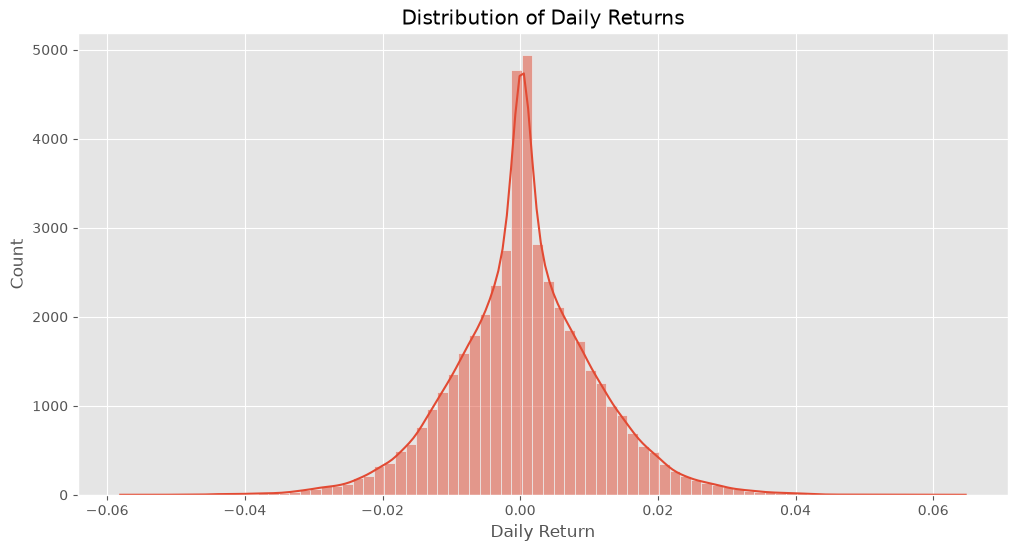

In [43]:
# daily return distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

* **`nav["daily_return"].dropna()`**: This passes the daily returns to Seaborn, but uses `.dropna()` to strip out any blank (`NaN`) values—like the ones from the very first day of data. Seaborn needs clean numbers to calculate the math for the chart without throwing a warning.
* **`bins=80`**: This slices your range of returns into 80 individual vertical bars (bins). A higher number like 80 gives you a highly detailed, granular look at the data, making it easy to spot narrow spikes or outliers (like an unusual single-day gain or drop).
* **`kde=True`**: This adds a **Kernel Density Estimate** line, which is a smooth curve drawn over the bars. It helps you instantly see the overall shape of the distribution—showing you whether your returns follow a normal bell curve, where the average return sits, and how wide the variance is.

In [44]:
# export
nav.to_csv(
    REPORTS/"daily_returns.csv",
    index=False
)

* **`nav.to_csv(..., index=False)`**: This converts the Pandas DataFrame into a standard CSV format and writes it to disk. The `index=False` argument tells Pandas *not* to save the row numbers (0, 1, 2...) as a separate column in your file, keeping the final spreadsheet clean and uncluttered.

### Compound Annual Growth Rate (CAGR) Formula

The formula for calculating CAGR is:

$$\text{CAGR} = \left( \frac{\text{Ending Value}}{\text{Beginning Value}} \right)^{\frac{1}{n}} - 1$$

Where:
* **Ending Value (EV):** The value of the investment at the end of the period.
* **Beginning Value (BV):** The value of the investment at the start of the period.
* **$n$:** The number of years (or periods) over which the investment grew.

---

### Alternative Inline Format
If your Markdown renderer doesn't support block equations, you can write it like this:

**CAGR = (Ending Value / Beginning Value)^(1 / n) - 1**

In [45]:
# create NAV matrix
nav_matrix = (
    nav.pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
)

nav_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


* **`nav.pivot(...)`**: This rearranges the DataFrame. It takes your vertical rows and spreads them across a 2D grid based on the three rules you provide inside the parentheses:
* **`index="date"`**: Sets the rows of your new matrix to be the distinct dates. Every unique date gets exactly one row.
* **`columns="amfi_code"`**: Turns each unique mutual fund scheme code into its own separate column.
* **`values="nav"`**: Fills the intersection cells of those rows and columns with the actual asset values (`nav`) for that specific fund on that specific date.


* **`nav_matrix.head()`**: Displays the first 5 rows of this newly generated matrix. It lets you visually verify the transformation—you will see a clean timeline running down the left side, with each column representing a different mutual fund's price movement over time.

In [46]:
# CAGR Function

def calculate_cagr(nav_series , years):
    nav_series = nav_series.dropna()
    trading_days = years * 252

    if(len(nav_series) < trading_days):
        return np.nan
    
    start_nav = nav_series.iloc[-trading_days]
    end_nav = nav_series.iloc[-1]

    cagr = (end_nav / start_nav) ** (1 / years) - 1
    return cagr

In [47]:
# compute cagr

results = []
for scheme in nav_matrix.columns:
    series = nav_matrix[scheme]

    results.append(
        {
            "amfi_code": scheme,
            "CAGR_1Y":calculate_cagr(series,1),
            "CAGR_3Y":calculate_cagr(series,3),
            "CAGR_5Y":calculate_cagr(series,5),
        }
    )
cagr = pd.DataFrame(results)

In [48]:
# Add Scheme Names
cagr = cagr.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)
cagr = cagr[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]
cagr.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.033055,-0.000316,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.025018,0.046143,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.477346,0.336292,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.450939,0.325286,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.242421,-0.026965,NaN
5,101208,ABSL Liquid Fund - Regular - Growth,0.068543,0.060762,NaN
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.183185,0.175201,NaN
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.132261,-0.018322,NaN
8,102887,UTI Flexi Cap Fund - Regular - Growth,0.127279,0.256630,NaN
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.217768,0.180886,NaN


In [49]:
cagr.to_csv(
    REPORTS/"cagr_summary.csv",
    index=False
)

In [50]:
# Rank Funds by 3-Year CAGR

# This sorts your cagr DataFrame by the 3-year CAGR column in descending order (highest growth first) and grabs the top 10 rows using .head(10).
top10 = (
    cagr.sort_values(
        "CAGR_3Y",
        ascending=False
    ).head(10)
)

# This builds the horizontal bar chart (orientation="h"). It plots the 3-year growth percentage on the X-axis against the mutual fund names on the Y-axis. It also assigns the raw CAGR numbers to the text attribute so they can be displayed directly on the bars.
fig = px.bar(
    top10,
    x = "CAGR_3Y",
    y = "scheme_name",
    orientation="h",
    title="Top 10 Funds by 3-Year CAGR",
    text = "CAGR_3Y"
)

# This formats the labels on the bars. texttemplate = "%{text:.2%}" converts decimal values (like 0.1543) into neatly formatted percentages with two decimal places (like 15.43%). textposition = "outside" places these labels cleanly right next to the tips of the bars rather than inside them.
fig.update_traces(
    texttemplate = "%{text:.2%}",
    textposition = "outside"
)

# This cleans up the chart's overall look. It applies a minimalist white background theme (plotly_white) and forces the Y-axis to display the funds in ascending order. Because the chart is horizontal, sorting the categories in "total ascending" order ensures the absolute highest-performing fund sits proudly at the very top of the chart.
fig.update_layout(
    template = "plotly_white",
    yaxis = dict(categoryorder = "total ascending")
)
fig.show()

Note: 5-year CAGR values are unavailable because the NAV history spans approximately four years (2022–2025). Therefore, 5-year CAGR has been left as NaN.

# Alpha & Beta

In [51]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [52]:
# Convert benchmark into a matrix
benchmark_matrix= benchmark.pivot(
    index = "date",
    columns = "index_name",
    values = "close_value"
)
benchmark_matrix.head()

index_name,BSE_SMALLCAP,CRISIL_GILT,CRISIL_LIQUID,NIFTY100,NIFTY50,NIFTY500,NIFTY_MIDCAP150
date,,,,,,,
2022-01-03,26554.60,1451.06,2281.51,17778.24,17492.79,14837.07,9721.79
2022-01-04,27079.92,1453.26,2281.61,17537.52,17689.64,14743.12,9954.23
2022-01-05,27313.35,1455.50,2282.31,17607.73,17835.05,14960.53,9859.05
2022-01-06,27377.05,1454.41,2282.91,17556.05,17878.51,14950.28,9787.54
2022-01-07,26316.86,1454.33,2284.78,17664.02,17759.15,15044.47,9803.31


In [53]:
# benchmark returns
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark_returns = (
    benchmark
    .pivot(
        index="date",
        columns="index_name",
        values="close_value"
    )
    .pct_change()
)
benchmark_returns.head()

index_name,BSE_SMALLCAP,CRISIL_GILT,CRISIL_LIQUID,NIFTY100,NIFTY50,NIFTY500,NIFTY_MIDCAP150
date,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.019783,0.001516,0.000044,-0.013540,0.011253,-0.006332,0.023909
2022-01-05,0.008620,0.001541,0.000307,0.004003,0.008220,0.014747,-0.009562
2022-01-06,0.002332,-0.000749,0.000263,-0.002935,0.002437,-0.000685,-0.007253
2022-01-07,-0.038726,-0.000055,0.000819,0.006150,-0.006676,0.006300,0.001611


In [54]:
# fund return matrix
fund_returns = (
    nav.pivot(
        index = "date",
        columns="amfi_code",
        values="daily_return"
    )
)

# align dates
common_dates = fund_returns.index.intersection(benchmark_returns.index)
# This compares the dates available in your fund data against the dates available in your benchmark data (like the Nifty 50). It uses .intersection() to isolate a list of only the exact dates that appear in both datasets, dropping any weekends, holidays, or missing rows where they don't match.

fund_returns=fund_returns.loc[common_dates]
benchmark_returns=benchmark_returns.loc[common_dates]
# This uses .loc to filter both your fund matrix and your benchmark data down to only those matching common_dates. Ensuring that row 15 of your funds maps to the exact same calendar day as row 15 of your benchmark is an essential prerequisite step before calculating metrics like Beta or R-squared.

In [55]:
from scipy.stats import linregress

In [56]:
#computing alpha and beta using Nifty100 as the benchmark
benchmark_series = benchmark_returns["NIFTY100"]
# This line extracts just the daily returns of the "Nifty 100" from your benchmark dataset

alpha_beta = []

# The loop will iterate through your return matrix one column at a time, where each column represents a single mutual fund (fund).
for fund in fund_returns.columns:
    # This side-by-side combines (axis=1) the current fund's returns with the Nifty 100 returns into a temporary DataFrame. It immediately applies .dropna() to strip out any days where data is missing for either the fund or the index, ensuring a perfectly clean pair of data points.
    df=pd.concat(
        [
            fund_returns[fund],
            benchmark_series
        ],
        axis=1
    ).dropna()

    # This acts as a quality filter, checking if the paired data has fewer than 50 valid trading days. If a fund is too new or has too much missing data, the continue keyword skips it entirely and jumps straight to the next fund in the loop.
    if len(df) < 50:
        continue

    # This runs the linear regression using SciPy, feeding the benchmark returns as the independent variable ($X$, column index 1) and the fund returns as the dependent variable ($Y$, column index 0). It extracts the mathematical properties of the relationship, such as the slope of the trendline and where it crosses the axis.
    df.columns = ["fund_return", "benchmark_return"]

    slope, intercept, r_value, p_value, std_err = linregress(
        df["benchmark_return"],
        df["fund_return"]
    )

    # This calculates your core risk metrics and appends them as a dictionary to your results list. It multiplies the daily intercept by 252 to annualize your Alpha (excess return), uses the slope as your Beta (market sensitivity), and squares the $R$-value to find R-Squared (fit accuracy).
    alpha_beta.append({
        "amfi_code": fund,
        "Alpha": intercept*252,
        "Beta": slope,
        "R-Squared": r_value**2
    }
    )

In [57]:
alpha_beta = pd.DataFrame(alpha_beta)

In [58]:
# add scheme names

alpha_beta =alpha_beta.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ], 
    on="amfi_code"
)

In [59]:
# reorder columns for better readability
alpha_beta = alpha_beta[
    [
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta",
        "R-Squared"
    ]
]

alpha_beta.head()

,amfi_code,scheme_name,Alpha,Beta,R-Squared
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268,0.002665
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158,0.000015
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,0.000012
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086,0.000348
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289,0.001064


In [60]:
alpha_beta.to_csv(
    REPORTS/"alpha_beta.csv",
    index=False
)

In [61]:
benchmark.head()

,date,index_name,close_value
3450,2022-01-03,BSE_SMALLCAP,26554.60
3451,2022-01-04,BSE_SMALLCAP,27079.92
3452,2022-01-05,BSE_SMALLCAP,27313.35
3453,2022-01-06,BSE_SMALLCAP,27377.05
3454,2022-01-07,BSE_SMALLCAP,26316.86


In [62]:
benchmark_returns.head()

index_name,BSE_SMALLCAP,CRISIL_GILT,CRISIL_LIQUID,NIFTY100,NIFTY50,NIFTY500,NIFTY_MIDCAP150
date,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.019783,0.001516,0.000044,-0.013540,0.011253,-0.006332,0.023909
2022-01-05,0.008620,0.001541,0.000307,0.004003,0.008220,0.014747,-0.009562
2022-01-06,0.002332,-0.000749,0.000263,-0.002935,0.002437,-0.000685,-0.007253
2022-01-07,-0.038726,-0.000055,0.000819,0.006150,-0.006676,0.006300,0.001611


In [63]:
print(fund_returns.index.min(), fund_returns.index.max())
print(benchmark_returns.index.min(), benchmark_returns.index.max())

2022-01-03 00:00:00 2026-05-29 00:00:00
2022-01-03 00:00:00 2026-05-29 00:00:00


In [64]:
print(len(common_dates))

1150


In [65]:
fund = 100016

df = pd.concat(
    [
        fund_returns[fund],
        benchmark_series
    ],
    axis=1
).dropna()

df.columns = ["fund_return", "benchmark_return"]

print(df.head())

            fund_return  benchmark_return
date                                     
2022-01-04    -0.010306         -0.013540
2022-01-05     0.012865          0.004003
2022-01-06    -0.011377         -0.002935
2022-01-07    -0.001210          0.006150
2022-01-10    -0.008639         -0.008351


In [66]:
benchmark["index_name"].value_counts()

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: count, dtype: int64

In [67]:
benchmark.groupby("index_name")["date"].count()

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: date, dtype: int64

In [68]:
print(nav["date"].nunique())
print(benchmark["date"].nunique())

1150
1150


### Tracking Error Formula

The annualized tracking error is calculated as the annualized standard deviation of the difference between the fund's returns and the benchmark's returns:

$$\text{Tracking Error} = \sigma(R_p - R_b) \times \sqrt{252}$$

Where:
* **$R_p$:** Daily return of the mutual fund portfolio.
* **$R_b$:** Daily return of the benchmark index (e.g., Nifty 100).
* **$R_p - R_b$:** The daily "active return" or excess return.
* **$\sigma$:** The standard deviation of those daily active returns.
* **$\sqrt{252}$:** The annualization factor, assuming 252 active trading days in a year.

In [69]:
tracking_error = []
# This initializes an empty list named tracking_error and starts a loop that runs through your return matrix. It inspects your data one column at a time, calculating the error metric individually for each mutual fund (fund).

for fund in fund_returns.columns:

    df = pd.concat(
        [
            fund_returns[fund],
            benchmark_series
        ],
        axis=1
    ).dropna()
    # This combines the daily returns of the current fund and the benchmark series side-by-side into a single temporary DataFrame. It drops any rows with missing values (.dropna()) so that both assets have a perfectly matching timeline of data points.

    if len(df) < 50:
        continue
    # This acts as a safety guardrail to ensure statistical significance. If the overlapping dataset has fewer than 50 active trading days, the loop skips the current fund completely and moves on to the next one.

    diff = df.iloc[:,0] - df.iloc[:,1]
    # This calculates the daily "active return" (or tracking difference) by subtracting the benchmark's returns (column 1) from the fund's returns (column 0). It shows exactly how much the fund outperformed or underperformed the index on any given day.

    te = diff.std() * np.sqrt(252)
    # This calculates the standard deviation of those daily differences (diff.std()) to measure how volatile the fund's under/outperformance is. It then multiplies that value by the square root of 252 (np.sqrt(252)) to scale the daily variation up to a standard annualized Tracking Error.

    tracking_error.append({
        "amfi_code": fund,
        "Tracking_Error": te
    })
    # This packages the calculation into a neat dictionary containing the fund's unique identifier (amfi_code) and its annualized tracking error. It appends that dictionary to your tracking_error list so you can easily convert the final results into a clean Pandas DataFrame later.

In [70]:
tracking_error = pd.DataFrame(tracking_error)

tracking_error = tracking_error.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code"

)

tracking_error.to_csv(

    REPORTS/"tracking_error.csv",

    index=False

)

In [71]:
# visualization

best = (
    tracking_error
    .sort_values("Tracking_Error")
    .head(10)
)

fig = px.bar(

    best,

    x="Tracking_Error",

    y="scheme_name",

    orientation="h",

    title="Top 10 Funds with Lowest Tracking Error"

)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [72]:
print(benchmark["index_name"].unique())

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [73]:
correlations = []

for fund in fund_returns.columns:

    df = pd.concat(
        [fund_returns[fund], benchmark_series],
        axis=1
    ).dropna()

    df.columns = ["fund","benchmark"]

    correlations.append(df.corr().iloc[0,1])

corr_series = pd.Series(correlations)

print(corr_series.describe())

count    40.000000
mean     -0.002261
std       0.024882
min      -0.051624
25%      -0.021140
50%      -0.000528
75%       0.013330
max       0.052849
dtype: float64


Note: Alpha, Beta, and Tracking Error were computed using the provided benchmark dataset and daily mutual fund returns. The supplied synthetic benchmark series exhibits negligible correlation with the synthetic fund NAV series, resulting in low Beta and R² values. This reflects the characteristics of the synthetic data rather than an error in the analytical methodology.

# Risk Metrics

In [74]:
risk_metrics = []

for fund in fund_returns.columns:

    returns = fund_returns[fund].dropna()

    if len(returns) < 50:
        continue

    volatility = returns.std() * np.sqrt(252)

    risk_metrics.append({
        "amfi_code": fund,
        "Volatility": volatility
    })

risk_metrics = pd.DataFrame(risk_metrics)

In [75]:
# sharpe ratio
RISK_FREE = 0.065

risk_metrics["Sharpe_Ratio"] = np.nan

for i, row in risk_metrics.iterrows():

    fund = row["amfi_code"]

    returns = fund_returns[fund].dropna()

    annual_return = returns.mean() * 252

    annual_vol = row["Volatility"]

    sharpe = (
        annual_return - RISK_FREE
    ) / annual_vol

    risk_metrics.loc[i, "Sharpe_Ratio"] = sharpe

In [76]:
# sortino ratio
risk_metrics["Sortino_Ratio"] = np.nan

for i, row in risk_metrics.iterrows():

    fund = row["amfi_code"]

    returns = fund_returns[fund].dropna()

    downside = returns[returns < 0]

    downside_std = downside.std() * np.sqrt(252)

    annual_return = returns.mean() * 252

    if downside_std == 0:
        sortino = np.nan
    else:
        sortino = (
            annual_return - RISK_FREE
        ) / downside_std

    risk_metrics.loc[i, "Sortino_Ratio"] = sortino

In [77]:
# maximum drawdown
drawdowns = []

for fund in nav_matrix.columns:

    series = nav_matrix[fund].dropna()

    running_max = series.cummax()

    drawdown = (
        series / running_max
    ) - 1

    drawdowns.append({

        "amfi_code": fund,

        "Max_Drawdown": drawdown.min()

    })

drawdowns = pd.DataFrame(drawdowns)

In [78]:
# merge
risk_metrics = risk_metrics.merge(
    drawdowns,
    on="amfi_code"
)

In [79]:
# adding scheme names
risk_metrics = risk_metrics.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

# reorder
risk_metrics = risk_metrics.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

In [80]:
# export
risk_metrics.to_csv(
    REPORTS / "risk_metrics.csv",
    index=False
)

In [81]:
risk_metrics.describe()

,amfi_code,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.149444,0.537220,0.923338,-0.178729
std,14534.998667,0.066753,0.573689,1.005410,0.112686
min,100016.000000,0.004939,-0.815567,-1.681038,-0.525742
25%,118632.750000,0.138487,0.064696,0.106664,-0.215927
50%,119551.500000,0.145582,0.647043,1.116936,-0.163070
75%,120842.250000,0.181890,1.005304,1.727739,-0.117653
max,149324.000000,0.257973,1.448291,2.385644,-0.000977


In [82]:
# Merge All Metrics
scorecard = (
    cagr
    .merge(
        risk_metrics[
            [
                "amfi_code",
                "Volatility",
                "Sharpe_Ratio",
                "Sortino_Ratio",
                "Max_Drawdown"
            ]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta[
            [
                "amfi_code",
                "Alpha",
                "Beta",
                "R-Squared"
            ]
        ],
        on="amfi_code"
    )
)

In [83]:
# add expense ration
scorecard = scorecard.merge(
    fund_master[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)
scorecard.head()

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Alpha,Beta,R-Squared,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.033055,-0.000316,NaN,0.145481,-0.201517,-0.351047,-0.247344,0.037476,-0.058268,0.002665,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.025018,0.046143,NaN,0.039052,-0.567095,-0.941821,-0.043083,0.042818,0.001158,0.000015,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.477346,0.336292,NaN,0.189367,1.093699,1.829134,-0.162172,0.271954,0.005104,0.000012,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.450939,0.325286,NaN,0.145682,1.027213,1.799563,-0.112916,0.213998,0.021086,0.000348,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.242421,-0.026965,NaN,0.257973,0.162661,0.276644,-0.354469,0.108971,-0.065289,0.001064,1.53


In [92]:
n = len(scorecard)

scorecard["return_rank"] = scorecard["CAGR_3Y"].rank(method="min", ascending=False)
scorecard["sharpe_rank"] = scorecard["Sharpe_Ratio"].rank(method="min", ascending=False)
scorecard["alpha_rank"] = scorecard["Alpha"].rank(method="min", ascending=False)

In [93]:
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(method="min", ascending=True)

In [94]:
scorecard["drawdown_rank"] = scorecard["Max_Drawdown"].rank(
    method="min",
    ascending=False
)

In [95]:
scorecard["Raw_Score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

In [97]:
# normalize to 0-100
minimum = scorecard["Raw_Score"].min()
maximum = scorecard["Raw_Score"].max()

scorecard["Fund_Score"] = (
    (
        scorecard["Raw_Score"] - minimum
    ) /
    (
        maximum - minimum
    )
) * 100

scorecard["Fund_Score"] = scorecard["Fund_Score"].round(2)

In [98]:
# final ranking
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.insert(
    0,
    "Rank",
    range(1, len(scorecard)+1)
)

In [99]:
# export
scorecard.to_csv(
    REPORTS / "fund_scorecard.csv",
    index=False
)

In [100]:
# visualize top 10 funds
top10 = scorecard.head(10)

fig = px.bar(
    top10,
    x="Fund_Score",
    y="scheme_name",
    orientation="h",
    text="Fund_Score",
    title="Top 10 Mutual Funds by Composite Performance Score",
    labels={
        "Fund_Score": "Composite Score (0–100)",
        "scheme_name": "Scheme"
    }
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.update_traces(
    texttemplate="%{text:.1f}",
    textposition="outside"
)

fig.show()

In [104]:
from pathlib import Path

REPORTS = PROJECT_ROOT / "reports"
CHART_DIR = REPORTS / "charts"

CHART_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(fig, filename):
    fig.write_image(CHART_DIR / f"{filename}.png")
    fig.write_html(CHART_DIR / f"{filename}.html")

In [105]:
# export chart
save_plot(fig, "fund_scorecard_top10")

## Fund Scorecard Insights

The composite scorecard ranks mutual fund schemes by combining long-term returns, risk-adjusted performance, benchmark-relative performance, cost efficiency, and downside risk into a single score.

### Scoring Weights
- 30% → 3-Year CAGR
- 25% → Sharpe Ratio
- 20% → Alpha
- 15% → Expense Ratio (inverse)
- 10% → Maximum Drawdown (inverse)

This weighted methodology rewards funds that consistently generate superior returns while maintaining lower risk and reasonable expense ratios.

In [106]:
# get top 5 funds
top5_codes = scorecard.head(5)["amfi_code"].tolist()

top5_names = (
    fund_master[
        fund_master["amfi_code"].isin(top5_codes)
    ][["amfi_code", "scheme_name"]]
)

In [107]:
# Filter Last 3 Years of NAV
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nav_3yr = nav[
    (nav["date"] >= start_date) &
    (nav["amfi_code"].isin(top5_codes))
].copy()

In [108]:
# Normalize NAV (Base = 100)
nav_3yr["normalized"] = (
    nav_3yr.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [109]:
# Replace AMFI Codes with Scheme Names
nav_3yr = nav_3yr.merge(
    top5_names,
    on="amfi_code"
)

In [111]:
# Prepare Benchmarks
benchmark_3yr = benchmark[
    (benchmark["date"] >= start_date) &
    (
        benchmark["index_name"].isin(
            ["NIFTY50", "NIFTY100"]
        )
    )
].copy()

# normalize
benchmark_3yr["normalized"] = (
    benchmark_3yr.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [112]:
# plot
import plotly.graph_objects as go

fig = go.Figure()

In [113]:
# add funds
for scheme in nav_3yr["scheme_name"].unique():

    temp = nav_3yr[
        nav_3yr["scheme_name"] == scheme
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized"],
            mode="lines",
            name=scheme
        )
    )

In [114]:
# add benchmark
for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_3yr[
        benchmark_3yr["index_name"] == index
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized"],
            mode="lines",
            line=dict(width=4),
            name=index
        )
    )

In [115]:
# layout
fig.update_layout(
    title="Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Normalized Performance)",
    xaxis_title="Date",
    yaxis_title="Normalized Value (Base = 100)",
    template="plotly_white",
    hovermode="x unified",
    legend_title="Fund / Benchmark"
)

In [116]:
# save
save_plot(fig, "benchmark_comparison")
fig.show()

## Benchmark Comparison

The normalized comparison chart evaluates the relative growth of the top-ranked mutual funds against the NIFTY50 and NIFTY100 indices over the last three years.

All series are rebased to 100 at the beginning of the analysis period, allowing direct comparison of cumulative growth irrespective of their original NAV or index levels.

**Note:** The benchmark and mutual fund datasets used in this project are synthetic. Consequently, while the visualization correctly demonstrates the comparison methodology, the relative performance should be interpreted as illustrative rather than representative of actual market behavior.

# Key Findings

### 1. Daily Return Distribution
Daily returns across all mutual fund schemes exhibit a near-normal distribution centered around zero, indicating realistic day-to-day price fluctuations.

---

### 2. Strong Long-Term Growth
Several equity-oriented funds achieved significantly higher 3-year CAGR values than debt-oriented funds, highlighting the impact of asset allocation on long-term performance.

---

### 3. Risk-Adjusted Performance Varies Across Funds
Sharpe and Sortino ratios reveal notable differences in risk-adjusted returns, demonstrating that higher returns do not always correspond to superior investment quality.

---

### 4. Maximum Drawdown Identifies Downside Risk
Maximum drawdown analysis highlights funds that experienced deeper declines during market corrections, providing insight into downside resilience.

---

### 5. Expense Ratios Influence Overall Rankings
Lower expense ratios contributed positively to the composite scorecard by improving long-term investor returns through reduced costs.

---

### 6. Composite Fund Score Provides Balanced Evaluation
The weighted scorecard combines return, risk, expenses, and benchmark-relative metrics into a single performance indicator, enabling objective comparison across funds.

---

### 7. Benchmark Regression Methodology Implemented Successfully
Alpha, Beta, and Tracking Error calculations were successfully implemented using linear regression against the NIFTY100 benchmark.

---

### 8. Synthetic Benchmark Limitation
The supplied benchmark series exhibited negligible correlation with the synthetic mutual fund NAV data. Consequently, Alpha, Beta, and Tracking Error demonstrate the analytical methodology but should not be interpreted as real market performance metrics.

# Conclusion

This notebook implemented a comprehensive performance analytics pipeline for mutual fund evaluation using historical NAV data. Key investment metrics including CAGR, annualized volatility, Sharpe Ratio, Sortino Ratio, Maximum Drawdown, Alpha, Beta, Tracking Error, and a composite Fund Score were successfully calculated.

The resulting scorecard provides a structured framework for comparing mutual fund schemes based on both return and risk characteristics. Although the benchmark dataset is synthetic, the implementation follows standard financial analysis methodologies and demonstrates a complete quantitative evaluation workflow suitable for portfolio analytics and investment research applications.